# Extração

In [ ]:
# Conecta o colab ao drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Instala as depedências necessárias
!pip install kagglehub[pandas-datasets]

In [ ]:
# Importa as bibliotecas necessárias
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pyarrow.dataset as ds
import os
import shutil

In [ ]:
# Define os arquivos a serem lidos
produtos = "amazon_products.csv"
categorias = "amazon_categories.csv"

# Carrega o dataset de produtos
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/amazon-products-dataset-2023-1-4m-products",
  produtos
)

# Carrega o dataset de categorias
dim_category = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/amazon-products-dataset-2023-1-4m-products",
  categorias
)

Using Colab cache for faster access to the 'amazon-products-dataset-2023-1-4m-products' dataset.
Using Colab cache for faster access to the 'amazon-products-dataset-2023-1-4m-products' dataset.


In [ ]:
df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1426337 non-null  object 
 1   title              1426336 non-null  object 
 2   imgUrl             1426337 non-null  object 
 3   productURL         1426337 non-null  object 
 4   stars              1426337 non-null  float64
 5   reviews            1426337 non-null  int64  
 6   price              1426337 non-null  float64
 7   listPrice          1426337 non-null  float64
 8   category_id        1426337 non-null  int64  
 9   isBestSeller       1426337 non-null  bool   
 10  boughtInLastMonth  1426337 non-null  int64  
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 110.2+ MB


# Análise inicial

### Quantidade de produtos por categoria

In [ ]:
produtos_por_categoria = df.groupby("category_id").size().reset_index(name="product_count")
produtos_por_categoria = produtos_por_categoria.merge(dim_category, left_on="category_id", right_on="id", how="left")
produtos_por_categoria = produtos_por_categoria.drop(columns=["id"])

produtos_por_categoria.sort_values(by="product_count", ascending=False)

,category_id,product_count,category_name
83,91,28619,Girls' Clothing
78,84,24660,Boys' Clothing
247,270,20846,Toys & Games
103,114,19822,Men's Shoes
105,118,18994,Women's Handbags
...,...,...,...
181,195,76,Smart Home: Lawn and Garden
172,186,50,Smart Home: Voice Assistants and Hubs
171,185,42,Smart Home: New Smart Devices
92,102,40,Garment Bags


### Categorias com maior volume de vendas

In [ ]:
produtos_por_categoria.sort_values(by="product_count", ascending=False).head(10)

,category_id,product_count,category_name
83,91,28619,Girls' Clothing
78,84,24660,Boys' Clothing
247,270,20846,Toys & Games
103,114,19822,Men's Shoes
105,118,18994,Women's Handbags
85,95,18514,Girls' Jewelry
100,110,18258,Men's Clothing
101,112,17679,Men's Accessories
104,116,17393,Women's Clothing
109,123,17005,Women's Jewelry


### Distribuição de preço

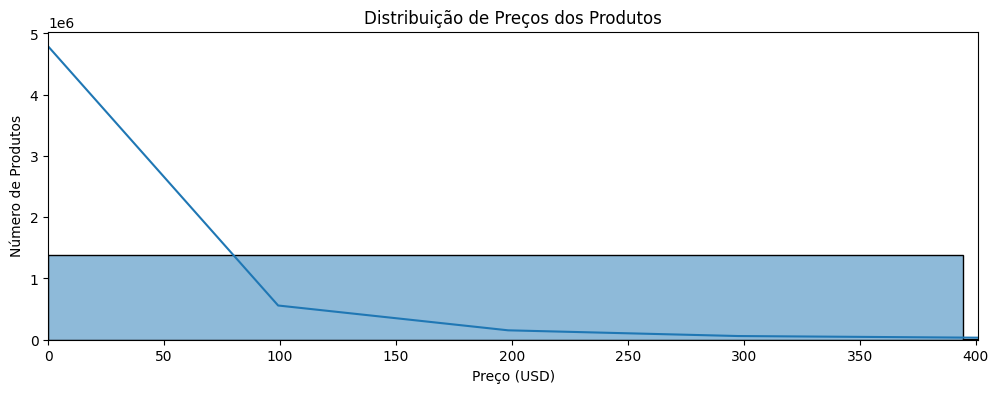

In [ ]:
plt.figure(figsize=(12, 4))

sns.histplot(df[df["price"] > 0]["price"], bins=50, kde=True)

plt.title("Distribuição de Preços dos Produtos")
plt.xlabel("Preço (USD)")
plt.ylabel("Número de Produtos")
plt.xlim(0, df["price"].quantile(0.99)) # Limita o eixo X para melhor visualização, removendo outliers extremos

plt.show()

### Distribuição de rating

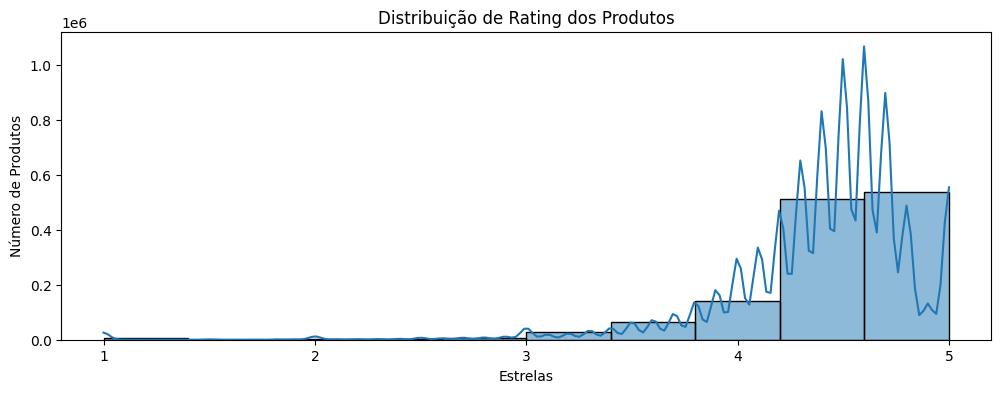

In [ ]:
plt.figure(figsize=(12, 4))

sns.histplot(df[df["stars"] > 0]["stars"], bins=10, kde=True)

plt.title("Distribuição de Rating dos Produtos")
plt.xlabel("Estrelas")
plt.ylabel("Número de Produtos")
plt.xticks(range(1, 6)) # Define os ticks do eixo X para mostrar de 1 a 5 estrelas

plt.show()

### Quantidade de produtos sem preço

In [ ]:
produtos_sem_preco = df[df["price"] == 0].shape[0]
print(f"Número de produtos sem preço: {produtos_sem_preco}")

Número de produtos sem preço: 32772


### Quantidade de produtos com rating zero

In [ ]:
produtos_com_rating_zero = df[df["stars"] == 0].shape[0]
print(f"Número de produtos com rating zero: {produtos_com_rating_zero}")

Número de produtos com rating zero: 131023


### Porcentagem de valores nulos por coluna

In [ ]:
print(df.isnull().sum() * 100 / len(df))

asin                 0.00000
title                0.00007
imgUrl               0.00000
productURL           0.00000
stars                0.00000
reviews              0.00000
price                0.00000
listPrice            0.00000
category_id          0.00000
isBestSeller         0.00000
boughtInLastMonth    0.00000
dtype: float64


### Preço mínimo e máximo dos produtos (detecção de outliers)

In [ ]:
min_price = df["price"].min()
max_price = df["price"].max()

print(f"Preço mínimo: ${min_price:.2f}")
print(f"Preço máximo: ${max_price:.2f}")

Preço mínimo: $0.00
Preço máximo: $19731.81


# Tratamento

## Preço

### Remover preço igual a zero

In [ ]:
df_silver = df[df["price"] > 0]

### Remover outliers acima de P99

In [ ]:
p99_price = df_silver["price"].quantile(0.99)
df_silver = df_silver[df_silver["price"] <= p99_price].copy()

print(f"Outliers de preço acima do percentil 99 removidos. Preço máximo agora é: ${df_silver["price"].max():.2f}")

Outliers de preço acima do percentil 99 removidos. Preço máximo agora é: $413.45


### Segmentação de produtos por preço

In [ ]:
precos_por_quartil = df_silver["price"].quantile([0.25, 0.50, 0.75])

# Define os limites para cada segmento
bins = [0, precos_por_quartil[0.25], precos_por_quartil[0.50], precos_por_quartil[0.75], df_silver["price"].max()]
labels = ["budget", "mid", "premium", "luxury"]

# Cria a nova coluna "price_segment"
df_silver["price_segment"] = pd.cut(df_silver["price"], bins=bins, labels=labels, right=True, include_lowest=True)

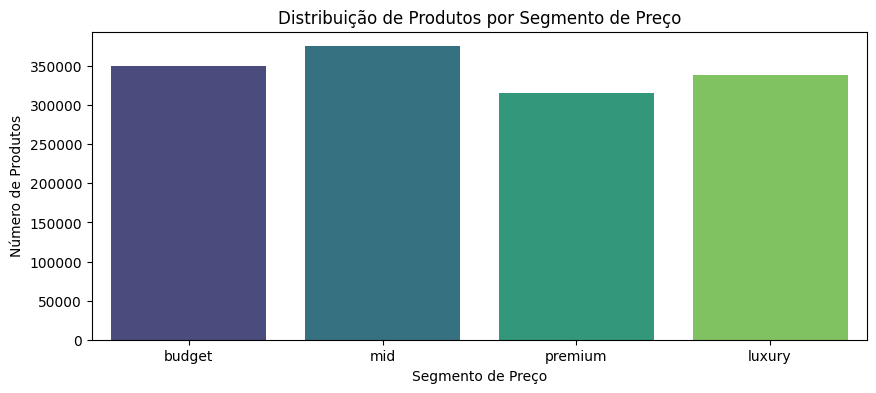

In [ ]:
plt.figure(figsize=(10, 4))

sns.countplot(x="price_segment", data=df_silver, order=labels, palette="viridis", hue="price_segment")

plt.title("Distribuição de Produtos por Segmento de Preço")
plt.xlabel("Segmento de Preço")
plt.ylabel("Número de Produtos")

plt.show()

## Rating

### Separar rating zero de rating real

In [ ]:
df_silver["has_rating"] = df_silver["stars"] > 0

### Avaliação ponderada (reviews)

In [ ]:
df_silver["weighted_score"] = df_silver["stars"] * np.log(1 + df_silver["reviews"])

## Popularidade

### Segmentação de produtos por popularidade

In [ ]:
# Define os quartis para "boughtInLastMonth" para criar os segmentos de popularidade
perc_popularidade = df_silver["boughtInLastMonth"].quantile([0.33, 0.66])

# Define os limites dos bins e os rótulos para as categorias
bins_popularity = [0, perc_popularidade[0.33], perc_popularidade[0.66], df_silver["boughtInLastMonth"].max()]
labels_popularity = ["low", "medium", "high"]

# Cria a nova coluna "popularity_tier"
df_silver["popularity_tier"] = pd.qcut(df_silver["boughtInLastMonth"].rank(method="first"), q=3, labels=["low", "medium", "high"])

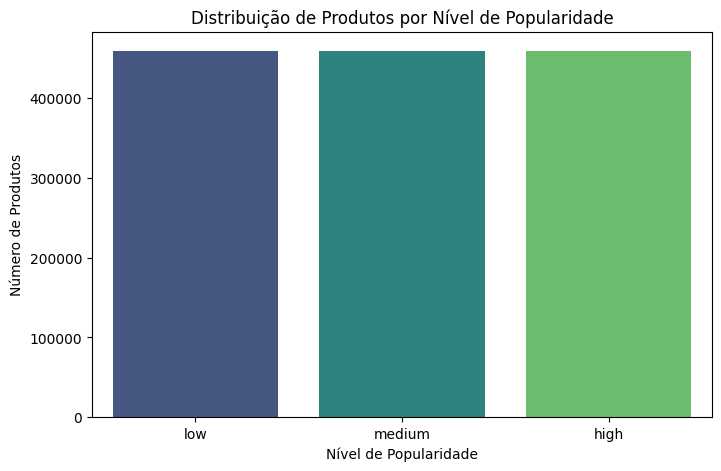

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="popularity_tier", data=df_silver, order=labels_popularity, palette="viridis", hue="popularity_tier")

plt.title("Distribuição de Produtos por Nível de Popularidade")
plt.xlabel("Nível de Popularidade")
plt.ylabel("Número de Produtos")

plt.show()

### Ranking por categoria

In [ ]:
# Juntar os dataframes para ter os nomes das categorias
df_ranked = pd.merge(df_silver, dim_category, left_on="category_id", right_on="id", how="left")

# Classificar os produtos dentro de cada categoria por weighted_score e boughtInLastMonth
df_ranked["rank_within_category_score"] = df_ranked.groupby("category_id")["weighted_score"].rank(ascending=False)
df_ranked["rank_within_category_sales"] = df_ranked.groupby("category_id")["boughtInLastMonth"].rank(ascending=False)

### Melhores produtos por categoria, baseado no weighted_score

In [ ]:
top_products_by_score = df_ranked.sort_values(by=["category_id", "rank_within_category_score"]).groupby("category_id").head(5)

# Descobrir quais as categorias com mais produtos
top_categories = df_ranked.groupby("category_id")["weighted_score"].sum().nlargest(3).index

# Filtrar o dataframe apenas para essas categorias
top_sampled = top_products_by_score[top_products_by_score["category_id"].isin(top_categories)]

# Executa o loop apenas para essa amostra
for category_id, group in top_sampled.groupby("category_id"):
    category_name = group["category_name"].iloc[0] if not group["category_name"].isnull().all() else f"ID: {category_id}"

    print(f"\n--- Categoria: {category_name} ---")
    display(group[["title", "stars", "reviews", "weighted_score", "boughtInLastMonth", "rank_within_category_score"]])


--- Categoria: Girls' Clothing ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_score
215700,"Babies, Toddlers, and Girls' 6-Piece Snug-Fit ...",4.8,45445,51.476544,400,1.0
73163,"Babies, Toddlers, and Girls' 6-Piece Snug-Fit ...",4.8,45425,51.474432,300,2.0
215691,Girls' Tag Free Cotton Brief Underwear Multipacks,4.7,52740,51.103798,1000,3.0
73009,Girls' Tag Free Cotton Brief Underwear Multipacks,4.7,52699,51.100142,1000,4.0
73076,Toddlers and Baby Girls' Loose-Fit Flame Resis...,4.8,34476,50.150629,300,5.0



--- Categoria: Girls' Jewelry ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_score
200176,Inspirational Bracelets for Women Mom Personal...,4.7,36119,49.324629,0,1.0
199275,Bracelets for Women Personalized Inspirational...,4.7,27463,48.036967,0,2.0
195104,Bracelets for Women Mothers Day Bracelet Gifts...,4.8,21284,47.835638,100,3.0
196722,"Gold Initial Necklaces for Women Girls, 14K Go...",4.6,23450,46.288275,0,4.0
197478,"Dainty Layered Choker Necklace, Handmade 14K G...",4.5,21649,44.922423,0,5.0



--- Categoria: Women's Handbags ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_score
229409,Wallet Women RFID Blocking Bifold Multi Card W...,4.5,68048,50.075925,2000,1.0
229476,Womens Rfid Blocking Small Compact Bifold Luxu...,4.6,40261,48.774552,1000,2.0
230308,Lightweight Medium Crossbody Bag with Tassel,4.6,31477,47.642403,300,3.0
229358,Triple Zip Small Crossbody Bag,4.6,29169,47.292122,2000,4.0
229932,Women's Cotton Zip Id Case Wallet,4.8,17919,47.009629,800,5.0


### Melhores produtos por categoria, baseado em boughtInLastMonth

In [ ]:
top_products_by_sales = df_ranked.sort_values(by=["category_id", "rank_within_category_sales"]).groupby("category_id").head(5)

# Descobrir quais as categorias com mais produtos
top_categories = df_ranked.groupby("category_id")["boughtInLastMonth"].sum().nlargest(3).index

# Filtrar o dataframe apenas para essas categorias
top_sampled = top_products_by_sales[top_products_by_sales['category_id'].isin(top_categories)]

# Executa o loop apenas para essa amostra
for category_id, group in top_sampled.groupby("category_id"):
    category_name = group["category_name"].iloc[0] if not group["category_name"].isnull().all() else f"ID: {category_id}"

    print(f"\n--- Categoria: {category_name} ---")
    display(group[["title", "stars", "reviews", "weighted_score", "boughtInLastMonth", "rank_within_category_sales"]])


--- Categoria: Hair Care Products ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_sales
467275,PURA D'OR Anti-Thinning Biotin Shampoo and Con...,4.3,0,0.0,20000,1.0
467277,"Pro Tools Detangler Comb, Wide Tooth Comb Deta...",4.7,0,0.0,10000,10.5
467280,Mielle Organics Rosemary Mint Strengthening Le...,4.5,0,0.0,10000,10.5
467371,L'Oréal Paris EverPure Moisture Sulfate Free S...,4.5,0,0.0,10000,10.5
467372,5Pcs Professional Salon Hair Coloring Dyeing K...,4.7,0,0.0,10000,10.5



--- Categoria: Industrial & Scientific ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_sales
665764,"Charmin Flushable Wipes, 4 packs, 40 Wipes Per...",4.5,0,0.0,40000,1.0
665815,Quencher H2.0 FlowState Stainless Steel Vacuum...,4.7,0,0.0,30000,2.0
665766,Quencher H2.0 FlowState Stainless Steel Vacuum...,4.7,0,0.0,20000,9.5
665767,ZeroWater Official Replacement Filter - 5-Stag...,4.6,0,0.0,20000,9.5
665812,"Scotch Super Glue Gel, .07 oz, 2-Pack, Dries Q...",4.5,0,0.0,20000,9.5



--- Categoria: Kitchen & Dining ---


,title,stars,reviews,weighted_score,boughtInLastMonth,rank_within_category_sales
980721,"Nespresso Capsules VertuoLine, Medium and Dark...",4.8,0,0.0,100000,1.5
980723,"Dixie Paper Plates, 8 1/2 inch, Dinner Size Pr...",4.8,0,0.0,100000,1.5
980725,"Nespresso Capsules VertuoLine, Melozio, Medium...",4.8,0,0.0,80000,3.0
980724,"Bounty Paper Napkins, White, 200 Count (Packag...",4.8,0,0.0,70000,4.5
980726,"Dixie 10 Inch Paper Plates, Dinner Size Printe...",4.8,0,0.0,70000,4.5


# Carregamento

## Camada bronze (arquivo raw do kaggle)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1426337 non-null  object 
 1   title              1426336 non-null  object 
 2   imgUrl             1426337 non-null  object 
 3   productURL         1426337 non-null  object 
 4   stars              1426337 non-null  float64
 5   reviews            1426337 non-null  int64  
 6   price              1426337 non-null  float64
 7   listPrice          1426337 non-null  float64
 8   category_id        1426337 non-null  int64  
 9   isBestSeller       1426337 non-null  bool   
 10  boughtInLastMonth  1426337 non-null  int64  
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 110.2+ MB


In [ ]:
path_bronze = "/content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_bronze"

# Remove o diretório para evitar duplicidade dos dados
if os.path.exists(path_bronze):
    shutil.rmtree(path_bronze)

# Salva o dataframe em formato parquet com particionamento único
df.to_parquet(
    path_bronze,
    engine="pyarrow",
    partition_cols=["category_id"],
    index=False
)

## Camada silver (transformações e padronização)

### Padronização dos nomes das colunas com snake_case

In [ ]:
df_silver = df_silver.rename(columns={
    "asin": "product_id",
    "title": "product_title",
    "imgUrl": "image_url",
    "productURL": "product_url",
    "stars": "rating",
    "reviews": "review_count",
    "price": "price",
    "listPrice": "list_price",
    "category_id": "category_id",
    "isBestSeller": "is_best_seller",
    "boughtInLastMonth": "units_sold_last_month"
})

### Garantir que product_title não fique nulo

In [ ]:
df_silver["product_title"] = df_silver["product_title"].fillna("")
df_silver["has_title"] = df_silver["product_title"].ne("")

### Fixar schema (evitar mudanças silenciosas)

In [ ]:
df_silver = df_silver.astype({
    "product_id": "string",
    "product_title": "string",
    "image_url": "string",
    "product_url": "string",
    "category_id": "int32",
    "review_count": "int32",
    "units_sold_last_month": "int32",
    "is_best_seller": "bool",
    "has_rating": "bool",
    "rating": "float32",
    "price": "float32",
    "list_price": "float32",
    "weighted_score": "float32",
})

### Ordenação de colunas

In [ ]:
# Junta o dataframe da silver com a dimensão de categoria
df_silver = df_silver.merge(dim_category, left_on="category_id", right_on="id", how="left")
df_silver = df_silver.drop(columns=["id"])

ordenando_colunas = [
    "product_id",
    "product_title",
    "category_id",
    "category_name",
    "price",
    "list_price",
    "price_segment",
    "rating",
    "review_count",
    "has_rating",
    "weighted_score",
    "units_sold_last_month",
    "popularity_tier",
    "is_best_seller",
    "has_title",
    "image_url",
    "product_url",
]

df_silver = df_silver[ordenando_colunas]

### Padronizar tipos que atrapalham SQL / catálogo

In [ ]:
df_silver["price_segment"] = df_silver["price_segment"].astype("string")
df_silver["popularity_tier"] = df_silver["popularity_tier"].astype("string")
df_silver["category_name"] = df_silver["category_name"].astype("string")

### Verificação de qualidade

In [ ]:
assert df_silver["product_id"].is_unique, "product_id duplicado!"
assert (df_silver["price"] > 0).all(), "ainda existe price <= 0!"
assert df_silver["category_name"].isnull().sum() == 0, "Categoria sem nome!"

In [ ]:
df_silver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379629 entries, 0 to 1379628
Data columns (total 17 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   product_id             1379629 non-null  string 
 1   product_title          1379629 non-null  string 
 2   category_id            1379629 non-null  int32  
 3   category_name          1379629 non-null  string 
 4   price                  1379629 non-null  float32
 5   list_price             1379629 non-null  float32
 6   price_segment          1379629 non-null  string 
 7   rating                 1379629 non-null  float32
 8   review_count           1379629 non-null  int32  
 9   has_rating             1379629 non-null  bool   
 10  weighted_score         1379629 non-null  float32
 11  units_sold_last_month  1379629 non-null  int32  
 12  popularity_tier        1379629 non-null  string 
 13  is_best_seller         1379629 non-null  bool   
 14  has_title         

In [ ]:
path_silver = "/content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_silver"

# Remove o diretório para evitar duplicidade dos dados
if os.path.exists(path_silver):
    shutil.rmtree(path_silver)

# Salva o dataframe em formato parquet com particionamento único
df_silver.to_parquet(
    path_silver,
    engine="pyarrow",
    partition_cols=["price_segment", "popularity_tier"],
    index=False
)

### Carrega o dataset no formato parquet

In [ ]:
loaded_df = pd.read_parquet(path_silver, engine="pyarrow")

In [ ]:
loaded_df.head()

,product_id,product_title,category_id,category_name,price,list_price,rating,review_count,has_rating,weighted_score,units_sold_last_month,is_best_seller,has_title,image_url,product_url,price_segment,popularity_tier
0,B01M3RYHP0,Men's Tag-Free Cotton Briefs,110,Men's Clothing,8.38,22.99,4.6,0,True,0.0,4000,True,True,https://m.media-amazon.com/images/I/61Qz7eM36p...,https://www.amazon.com/dp/B01M3RYHP0,budget,high
1,B07P7M18C6,Energy Unisex Easy-On/Easy-Off Knee High Compr...,110,Men's Clothing,11.88,0.00,4.3,0,True,0.0,5000,False,True,https://m.media-amazon.com/images/I/8146gI8s+S...,https://www.amazon.com/dp/B07P7M18C6,budget,high
2,B0B62HGK2H,Hooded Rain Poncho Waterproof Raincoat Jacket ...,110,Men's Clothing,9.99,13.99,4.5,0,True,0.0,2000,False,True,https://m.media-amazon.com/images/I/61JNcVZCPF...,https://www.amazon.com/dp/B0B62HGK2H,budget,high
3,B01L8JJ57U,"Men's EcoSmart Fleece Sweatshirt, Cotton-Blend...",110,Men's Clothing,10.99,18.00,4.6,0,True,0.0,3000,False,True,https://m.media-amazon.com/images/I/71fyw1U54G...,https://www.amazon.com/dp/B01L8JJ57U,budget,high
4,B08MBFGL13,"Men's Max Cushioned Crew Socks, Moisture-Wicki...",110,Men's Clothing,11.00,0.00,4.6,0,True,0.0,4000,False,True,https://m.media-amazon.com/images/I/81vTEPIns+...,https://www.amazon.com/dp/B08MBFGL13,budget,high


In [ ]:
loaded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379629 entries, 0 to 1379628
Data columns (total 17 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   product_id             1379629 non-null  string 
 1   product_title          1379629 non-null  string 
 2   category_id            1379629 non-null  int32  
 3   category_name          1379629 non-null  string 
 4   price                  1379629 non-null  float32
 5   list_price             1379629 non-null  float32
 6   rating                 1379629 non-null  float32
 7   review_count           1379629 non-null  int32  
 8   has_rating             1379629 non-null  bool   
 9   weighted_score         1379629 non-null  float32
 10  units_sold_last_month  1379629 non-null  int32  
 11  is_best_seller         1379629 non-null  bool   
 12  has_title              1379629 non-null  bool   
 13  image_url              1379629 non-null  string 
 14  product_url       